# Trabalho Prático

Este notebook implementa e analisa algoritmos para o problema do Caixeiro Viajante (TSP), incluindo força bruta e heurística, conforme especificado no enunciado do trabalho.

Nesta seção, importamos as bibliotecas essenciais para manipulação de dados, geração de instâncias, implementação dos algoritmos e visualização dos resultados.

In [64]:
import numpy as np
import itertools
import time
import matplotlib.pyplot as plt
import random
import os

## Parte 01

### 1. Implementação do Algoritmo de Força Bruta

Implementar o método de força bruta para solucionar o problema, ou seja, um algoritmo que determina todas as possíveis rotas e escolhe a melhor, ou seja, a menor;

In [65]:
def tsp_forca_bruta(matriz):
    n = len(matriz)
    cidades = list(range(n))
    menor_distancia = float('inf')
    melhor_rota = None
    for perm in itertools.permutations(cidades[1:]):
        rota = [0] + list(perm) + [0]
        distancia = sum(matriz[rota[i], rota[i+1]] for i in range(n))
        if distancia < menor_distancia:
            menor_distancia = distancia
            melhor_rota = rota
    return melhor_rota, menor_distancia


### 2. Gerar instâncias de tamanho 2 até n e aplicar o método de força bruta

Gerar instâncias de tamanho 2 à n e aplicar o método implementado no item 1;

In [66]:
def gerar_matriz_tsp(n_cidades, peso_min=1, peso_max=100):
    matriz = np.random.randint(peso_min, peso_max+1, size=(n_cidades, n_cidades))
    np.fill_diagonal(matriz, 0)
    # Simetrizar para garantir grafo não-direcionado
    matriz = np.triu(matriz) + np.triu(matriz, 1).T
    return matriz

# Exemplo de geração de uma matriz para 5 cidades
n = 5
matriz_exemplo = gerar_matriz_tsp(n)
print(matriz_exemplo)
# Exemplo de uso:
rota, dist = tsp_forca_bruta(matriz_exemplo)
print('Melhor rota:', rota)
print('Distância:', dist)

[[ 0  5  5 24 88]
 [ 5  0 85 76 43]
 [ 5 85  0 27 53]
 [24 76 27  0 99]
 [88 43 53 99  0]]
Melhor rota: [0, 1, 4, 2, 3, 0]
Distância: 152


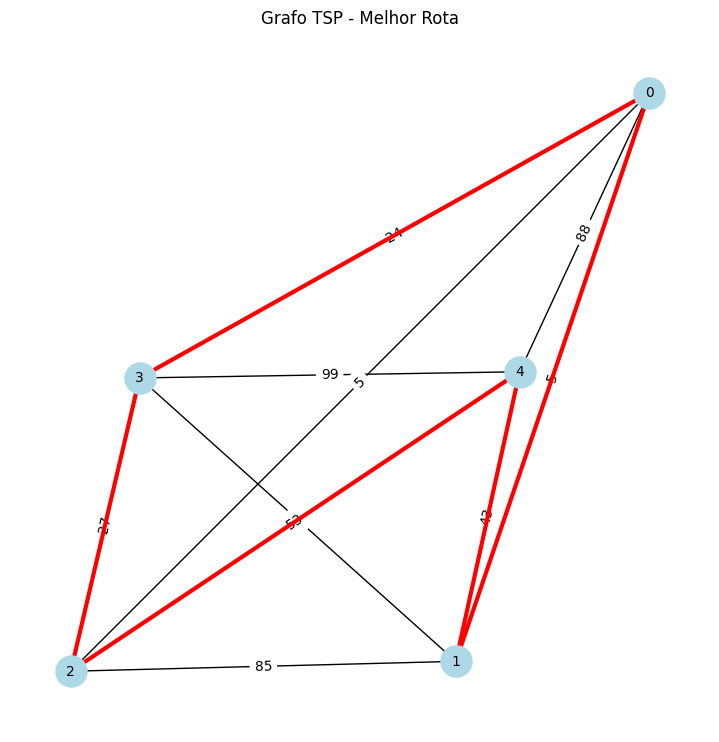

In [67]:
import networkx as nx
import matplotlib.pyplot as plt
import os

def plotar_grafo_tsp(matriz, rota=None, title="Grafo TSP", nome_arquivo=None):
    import networkx as nx
    import matplotlib.pyplot as plt
    import os

    n = len(matriz)
    G = nx.Graph()
    for i in range(n):
        G.add_node(i)
    for i in range(n):
        for j in range(i+1, n):
            if matriz[i, j] > 0:
                G.add_edge(i, j, weight=matriz[i, j])

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(7, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # Destacar a melhor rota em vermelho
    if rota is not None and len(rota) > 1:
        edges_rota = [(rota[i], rota[i+1]) for i in range(len(rota)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=edges_rota, edge_color='red', width=3)

    plt.title(title)
    if nome_arquivo is not None:
        if not os.path.exists('graficos'):
            os.makedirs('graficos')
        plt.savefig(f'graficos/{nome_arquivo}', bbox_inches='tight')
    plt.show()
# Exemplo de uso:
# Exemplo de uso:
plotar_grafo_tsp(matriz_exemplo, rota=rota, title="Grafo TSP - Melhor Rota", nome_arquivo="grafo_melhor_rota.png")

### 3. Computar o tempo de execução durante a aplicação da força bruta

Computar o tempo de execução durante a aplicação da força-bruta em cada uma das instâncias geradas. A aplicação do método deve ser realizada em quantas instâncias forem possíveis (possivelmente o tamanho máximo vai girar em torno de 10 a 14 cidades);

Obs.: as instâncias devem ser geradas de forma automática onde os pesos possuem valores aleatórios. Pode-se utilizar qualquer tipo de representação de grafos que se desejar.

Matriz para 2 cidades:
[[ 0 34]
 [34  0]]
2 cidades: tempo = 0.0000s, distância = 122, rota = [0, 1, 0]


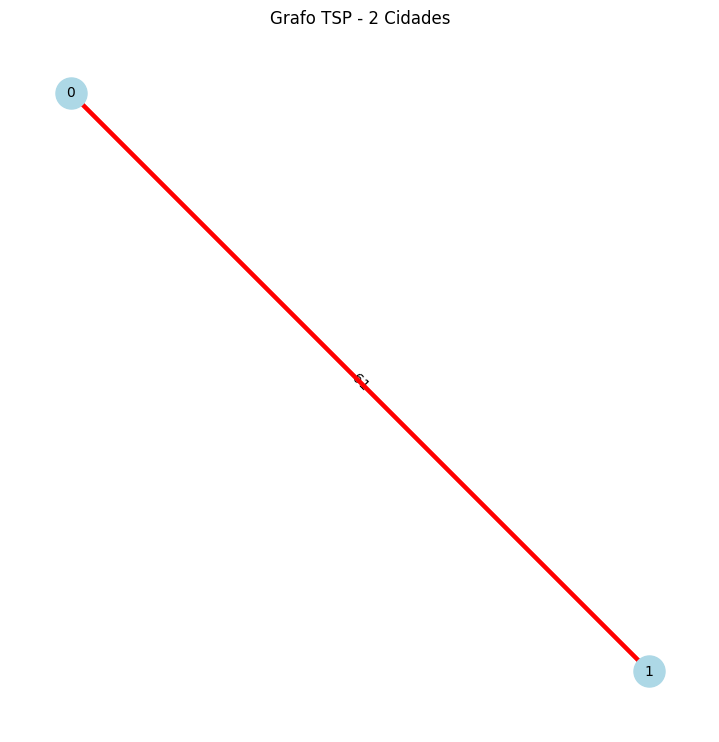

Matriz para 3 cidades:
[[ 0 29 70]
 [29  0 48]
 [70 48  0]]
3 cidades: tempo = 0.0000s, distância = 42, rota = [0, 1, 2, 0]


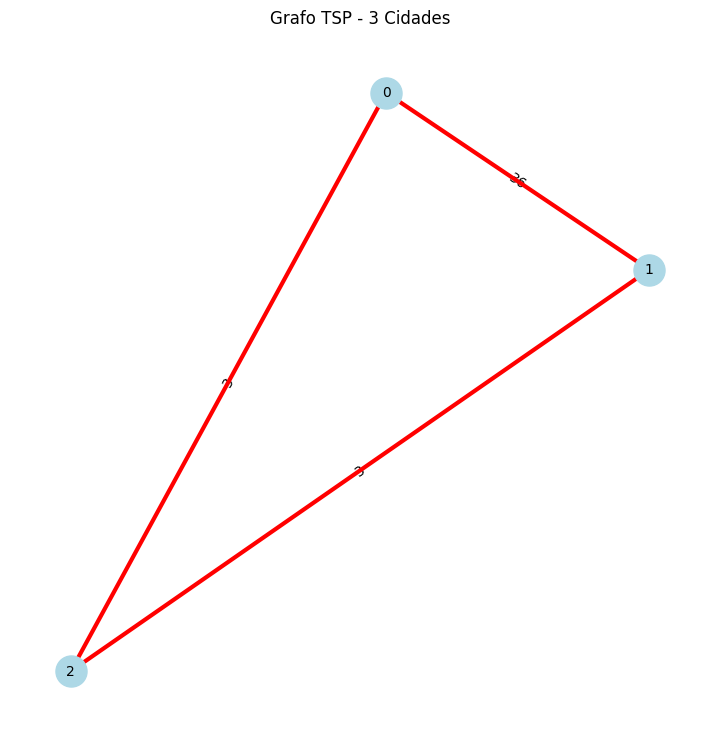

Matriz para 4 cidades:
[[ 0  8 87 29]
 [ 8  0  5 51]
 [87  5  0 10]
 [29 51 10  0]]
4 cidades: tempo = 0.0001s, distância = 221, rota = [0, 2, 1, 3, 0]


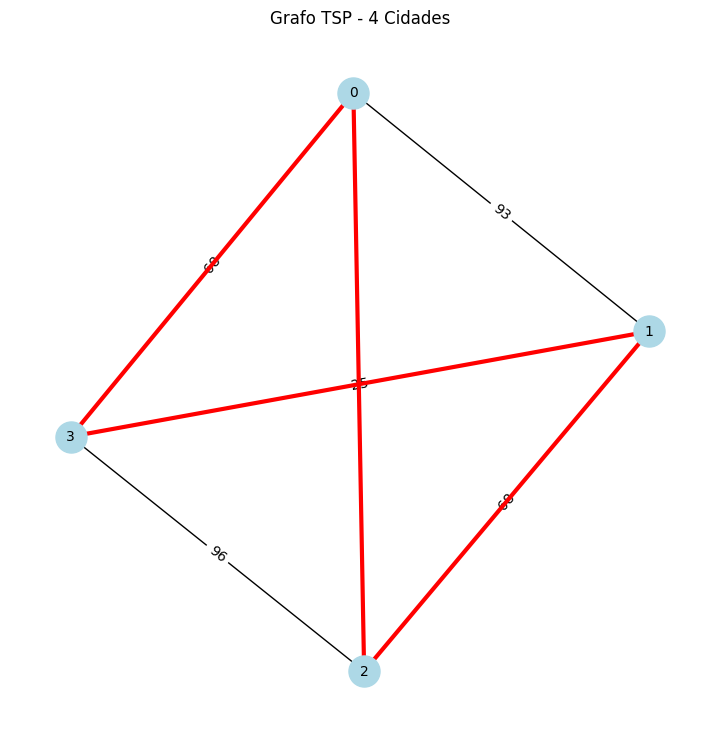

Matriz para 5 cidades:
[[ 0  8  6 77 83]
 [ 8  0 96 56 65]
 [ 6 96  0 10 17]
 [77 56 10  0 29]
 [83 65 17 29  0]]
5 cidades: tempo = 0.0002s, distância = 99, rota = [0, 1, 3, 4, 2, 0]


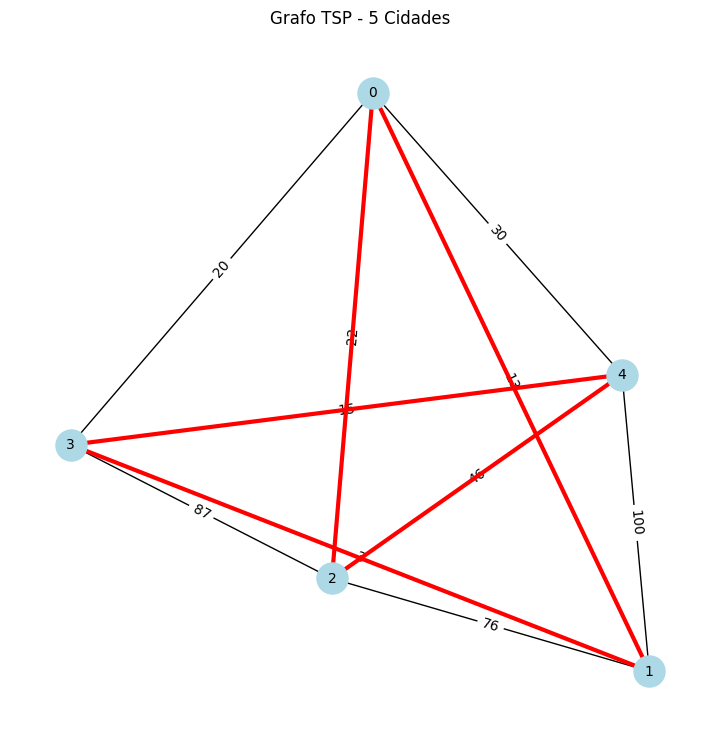

Matriz para 6 cidades:
[[ 0 51 16  1 53 53]
 [51  0 97 71 15 64]
 [16 97  0 74 34 34]
 [ 1 71 74  0 64 37]
 [53 15 34 64  0 94]
 [53 64 34 37 94  0]]
6 cidades: tempo = 0.0004s, distância = 89, rota = [0, 1, 2, 4, 3, 5, 0]


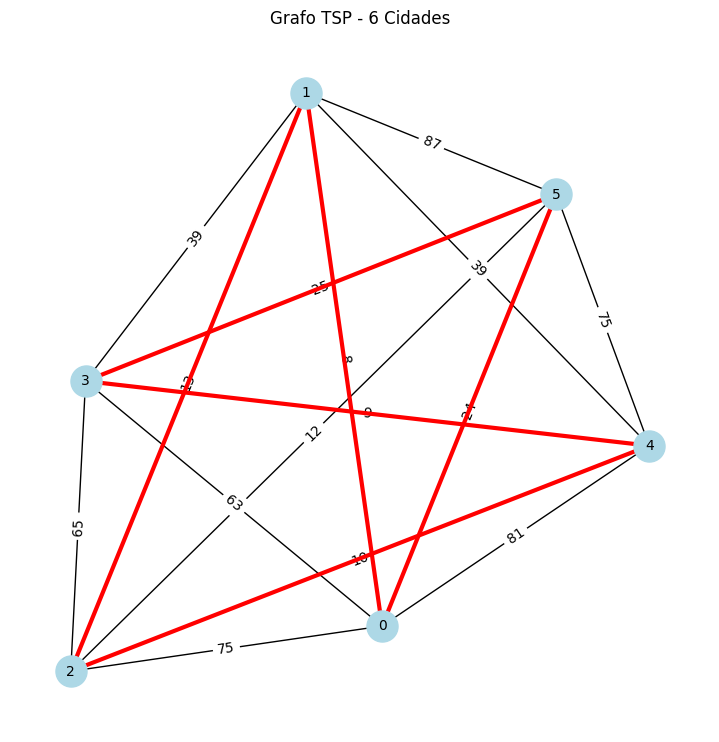

Matriz para 7 cidades:
[[ 0  7 74  7 15  9 43]
 [ 7  0 39 36 23 90 59]
 [74 39  0 48 60 93 93]
 [ 7 36 48  0 38 95 70]
 [15 23 60 38  0 15 53]
 [ 9 90 93 95 15  0 67]
 [43 59 93 70 53 67  0]]
7 cidades: tempo = 0.0027s, distância = 125, rota = [0, 1, 6, 5, 4, 3, 2, 0]


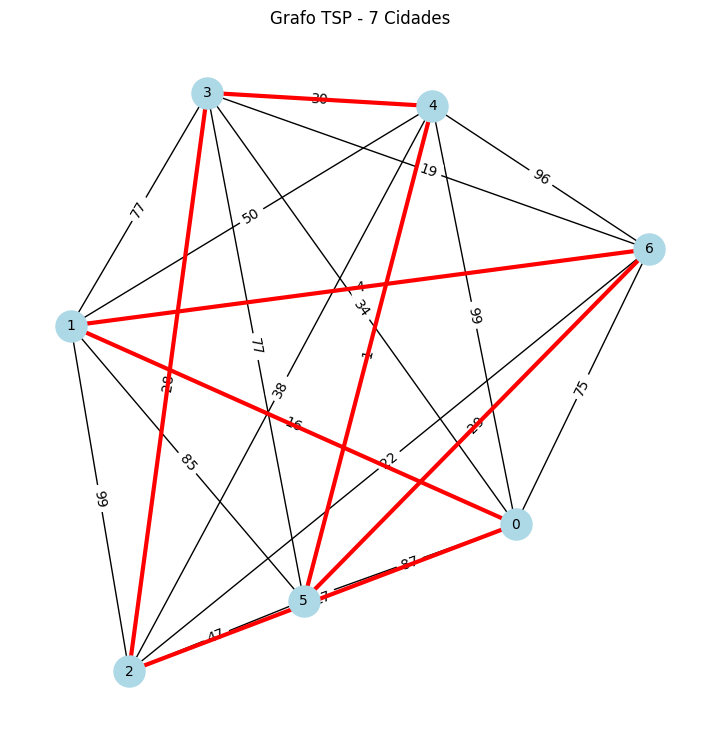

Matriz para 8 cidades:
[[ 0 65 29  4 88 65 16 36]
 [65  0 16 85 81 92 90 79]
 [29 16  0 64 83 12 39 14]
 [ 4 85 64  0 89 92 58 69]
 [88 81 83 89  0 74 44 22]
 [65 92 12 92 74  0  1 29]
 [16 90 39 58 44  1  0 39]
 [36 79 14 69 22 29 39  0]]
8 cidades: tempo = 0.0286s, distância = 165, rota = [0, 1, 2, 5, 3, 7, 6, 4, 0]


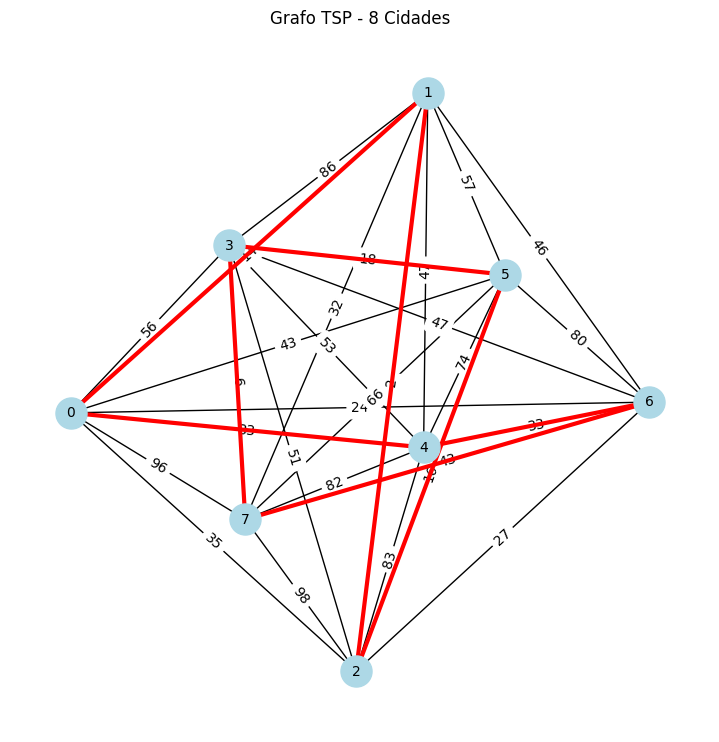

Matriz para 9 cidades:
[[  0   2  99  11  81  40  30  36  54]
 [  2   0  19  54  82  72  91  87  65]
 [ 99  19   0  96  74  56  24  27  90]
 [ 11  54  96   0  56  12  26  86   9]
 [ 81  82  74  56   0  24   3  84  94]
 [ 40  72  56  12  24   0  41  27  68]
 [ 30  91  24  26   3  41   0 100  79]
 [ 36  87  27  86  84  27 100   0   6]
 [ 54  65  90   9  94  68  79   6   0]]
9 cidades: tempo = 0.2144s, distância = 189, rota = [0, 2, 6, 5, 7, 8, 1, 4, 3, 0]


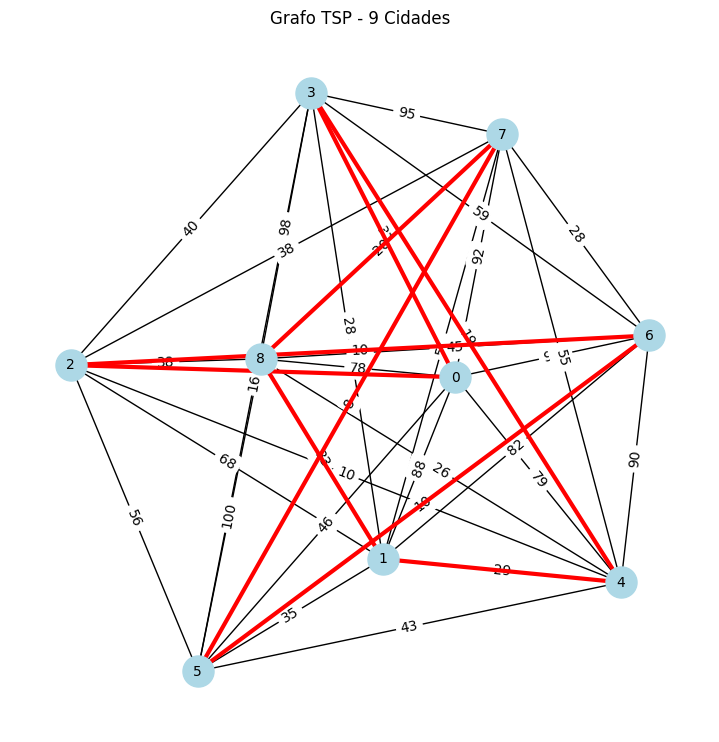

Matriz para 10 cidades:
[[  0  35  69  47  72  81  53  45  89  97]
 [ 35   0  91   2  14  51  67  41  98  42]
 [ 69  91   0  30  13  47  51  51   6  79]
 [ 47   2  30   0   8  92  54  93  45  74]
 [ 72  14  13   8   0  22   2  88  52  18]
 [ 81  51  47  92  22   0  11  84  42  42]
 [ 53  67  51  54   2  11   0   4  63  46]
 [ 45  41  51  93  88  84   4   0  25  92]
 [ 89  98   6  45  52  42  63  25   0 100]
 [ 97  42  79  74  18  42  46  92 100   0]]
10 cidades: tempo = 1.9179s, distância = 241, rota = [0, 5, 2, 1, 8, 4, 9, 3, 6, 7, 0]


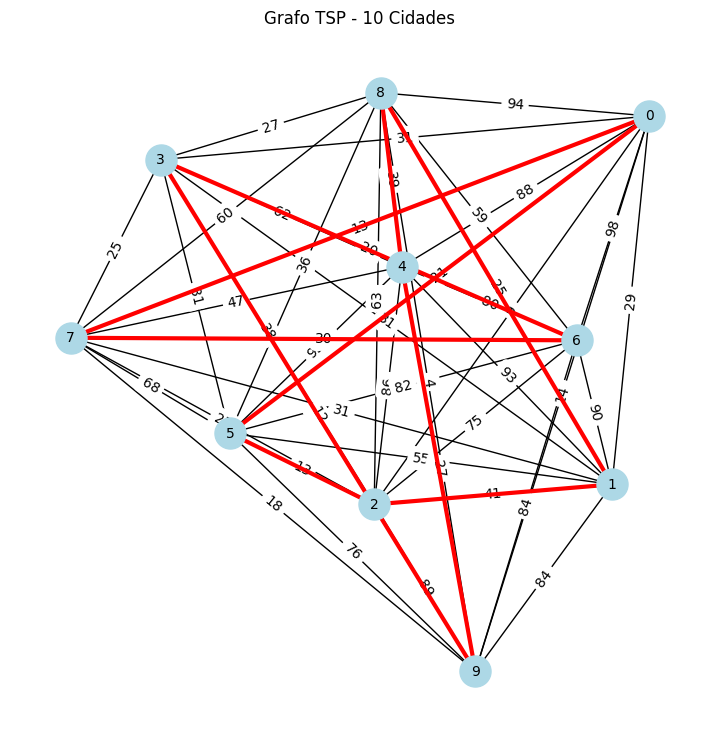

Matriz para 11 cidades:
[[ 0 26 83 82 82 97 62 10 27 66 67]
 [26  0 78 91 78 69 22 34 52 16 35]
 [83 78  0 46  9  6 54 30 76 34 61]
 [82 91 46  0 11 27 64 32 16 72 61]
 [82 78  9 11  0 65 40 18 20 87 45]
 [97 69  6 27 65  0 41 52 47 70  2]
 [62 22 54 64 40 41  0 66 31 93 11]
 [10 34 30 32 18 52 66  0 81 33 29]
 [27 52 76 16 20 47 31 81  0 28 57]
 [66 16 34 72 87 70 93 33 28  0  2]
 [67 35 61 61 45  2 11 29 57  2  0]]
11 cidades: tempo = 18.3764s, distância = 166, rota = [0, 3, 5, 7, 8, 1, 10, 4, 6, 2, 9, 0]


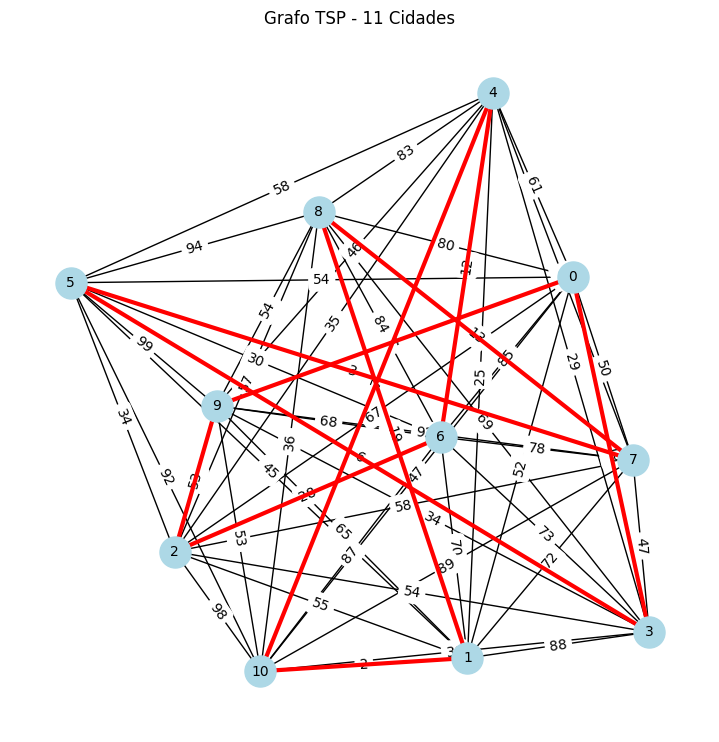

Matriz para 12 cidades:
[[ 0 84 41 46 48 44 70 34 93 27 72 48]
 [84  0 31 19 24 40 38 80 22 88 49 12]
 [41 31  0 93  9 71 51 45  8 73 10 10]
 [46 19 93  0 89 71 33 42 35  1 98  6]
 [48 24  9 89  0 77  9 93 93 73 37  2]
 [44 40 71 71 77  0 72 67 82 96 85 36]
 [70 38 51 33  9 72  0 59 44  1 15 57]
 [34 80 45 42 93 67 59  0 35 10 14 94]
 [93 22  8 35 93 82 44 35  0 88 50 16]
 [27 88 73  1 73 96  1 10 88  0 76 62]
 [72 49 10 98 37 85 15 14 50 76  0 47]
 [48 12 10  6  2 36 57 94 16 62 47  0]]
12 cidades: tempo = 208.8866s, distância = 277, rota = [0, 2, 1, 5, 9, 6, 11, 7, 4, 10, 8, 3, 0]


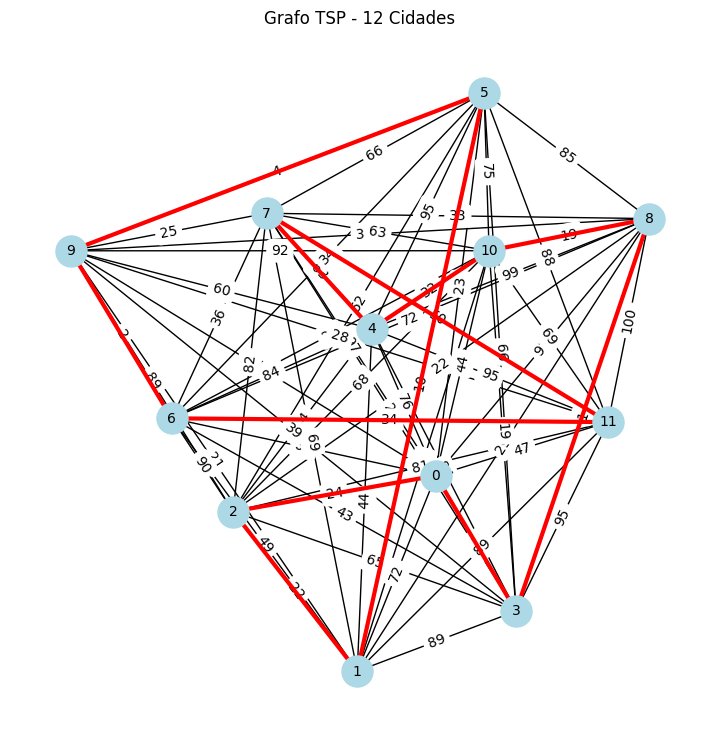

Matriz para 13 cidades:
[[ 0 26 14 62 26 27 91 44  1 74 77  6 51]
 [26  0 18 62 99 25 42  2 73 29 17 19 87]
 [14 18  0  3 73 34 78 13 65  4 89 14 57]
 [62 62  3  0 48 77 83 78 91 70 92 93  1]
 [26 99 73 48  0 24 38 44 40 16 24 65 49]
 [27 25 34 77 24  0  8 19 72  5  9 73 99]
 [91 42 78 83 38  8  0 42 44 48 36 58 88]
 [44  2 13 78 44 19 42  0 28 58 29  2 72]
 [ 1 73 65 91 40 72 44 28  0 86 89 47 62]
 [74 29  4 70 16  5 48 58 86  0  4 94 45]
 [77 17 89 92 24  9 36 29 89  4  0 26 53]
 [ 6 19 14 93 65 73 58  2 47 94 26  0 52]
 [51 87 57  1 49 99 88 72 62 45 53 52  0]]
13 cidades: tempo = 2721.4667s, distância = 166, rota = [0, 7, 11, 12, 8, 10, 5, 2, 1, 3, 6, 4, 9, 0]


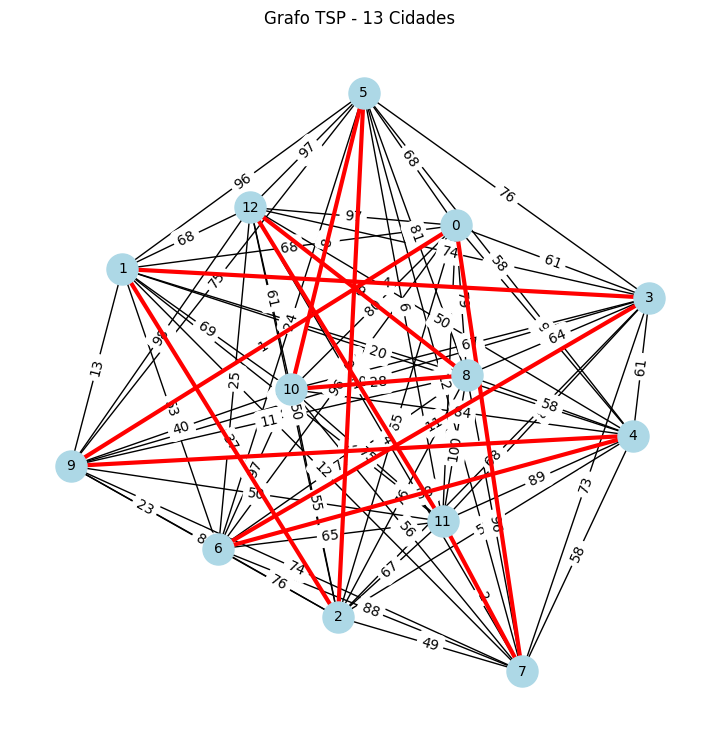

In [68]:
tempos = []
distancias = []
ns = list(range(2, 14)) 
for n in ns:
    matriz = gerar_matriz_tsp(n)
    inicio = time.time()
    rota, dist = tsp_forca_bruta(matriz)
    fim = time.time()
    tempos.append(fim - inicio)
    distancias.append(dist)
    #printar Matriz de adjacencia
    print(f'Matriz para {n} cidades:')
    print(gerar_matriz_tsp(n))
    # printar tempo e distância
    print(f'{n} cidades: tempo = {tempos[-1]:.4f}s, distância = {dist}, rota = {rota}')
    plotar_grafo_tsp(matriz, rota=rota, title=f"Grafo TSP - {n} Cidades", nome_arquivo=f"grafo_{n}_cidades.png")
  
    
    

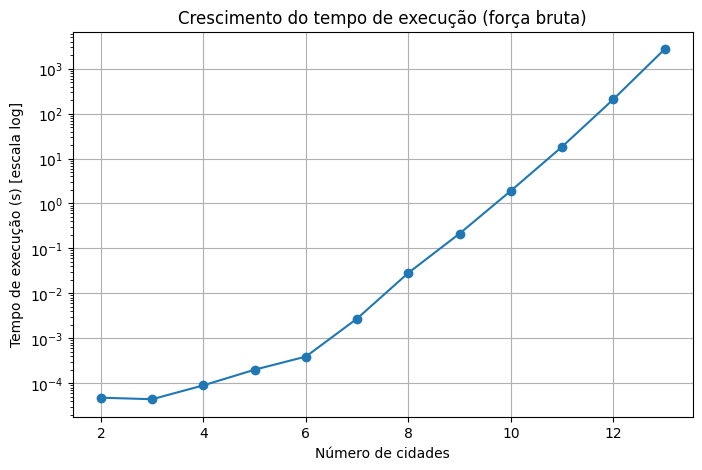

In [69]:
import os 
# Criando o diretório para salvar os gráficos, se não existir
if not os.path.exists('graficos'):
    os.makedirs('graficos')

plt.figure(figsize=(8,5))
plt.plot(ns, tempos, marker='o')
plt.yscale('log')
plt.xlabel('Número de cidades')
plt.ylabel('Tempo de execução (s) [escala log]')
plt.title('Crescimento do tempo de execução (força bruta)')
plt.grid(True)
plt.savefig('graficos/grafico_tempo_forca_bruta.png')
plt.show()

## Parte 2: Heurística 

### 1. Implementação de uma Heurística para o TSP

Aqui, implementamos uma heurística (vizinho mais próximo) para encontrar soluções aproximadas para o TSP.

In [79]:
def tsp_vizinho_mais_proximo(matriz, inicio=0):
    n = len(matriz)
    visitado = [False]*n
    rota = [inicio]
    visitado[inicio] = True
    atual = inicio
    for _ in range(n-1):
        proximos = [(i, matriz[atual][i]) for i in range(n) if not visitado[i]]
        prox, _ = min(proximos, key=lambda x: x[1])
        rota.append(prox)
        visitado[prox] = True
        atual = prox
    rota.append(inicio)
    distancia = sum(matriz[rota[i], rota[i+1]] for i in range(n))
    return rota, distancia

# Exemplo de uso:
rota_h, dist_h = tsp_vizinho_mais_proximo(matriz_exemplo)
print('Rota heurística:', rota_h)
print('Distância heurística:', dist_h)

Rota heurística: [0, 1, 4, 2, 3, 0]
Distância heurística: 152


Matriz para 2 cidades:
[[ 0 84]
 [84  0]]
2 cidades (heurística): tempo = 0.0000s, distância = 168, rota = [0, 1, 0]


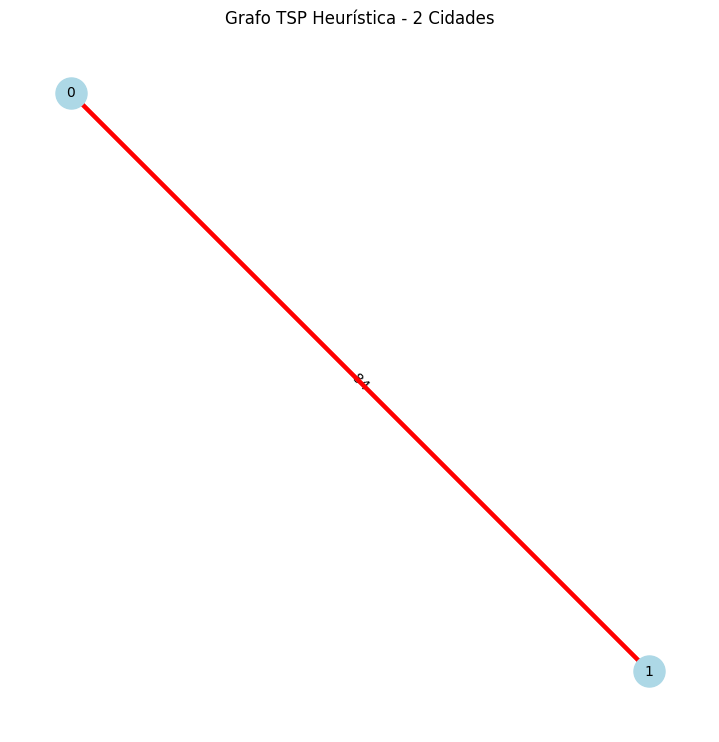

Matriz para 3 cidades:
[[ 0 87 78]
 [87  0 58]
 [78 58  0]]
3 cidades (heurística): tempo = 0.0000s, distância = 223, rota = [0, 2, 1, 0]


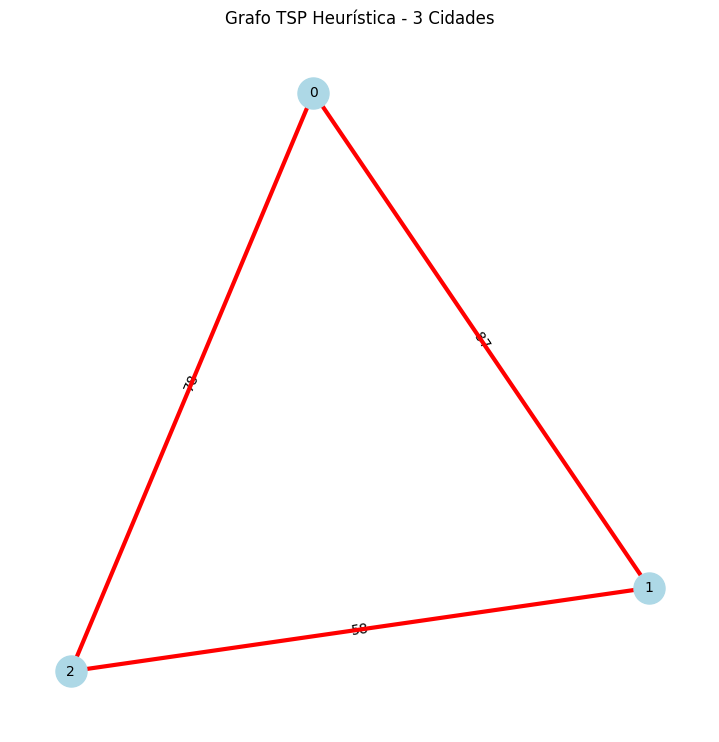

Matriz para 4 cidades:
[[ 0 84  5 82]
 [84  0 58  8]
 [ 5 58  0  4]
 [82  8  4  0]]
4 cidades (heurística): tempo = 0.0000s, distância = 101, rota = [0, 2, 3, 1, 0]


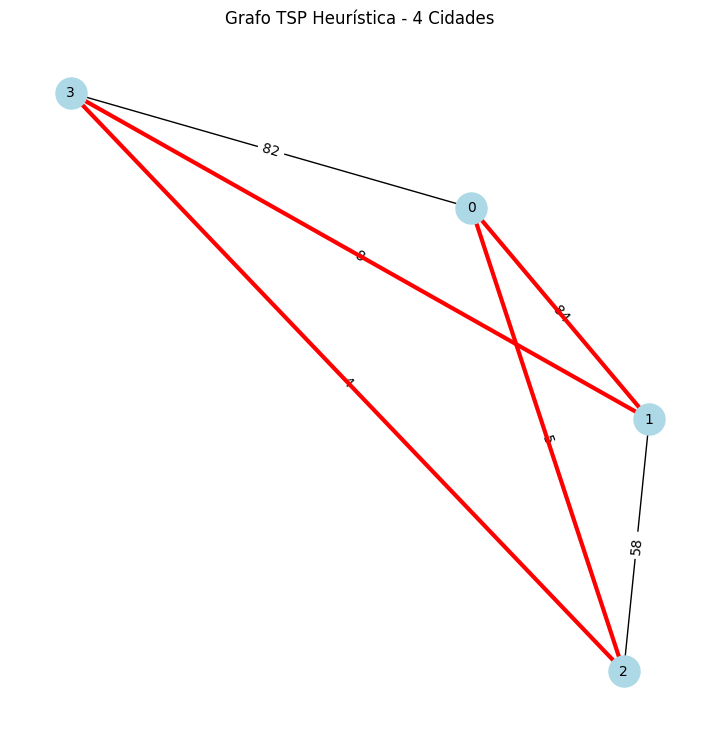

Matriz para 5 cidades:
[[ 0 51 96 54  9]
 [51  0 73 13 56]
 [96 73  0 77 54]
 [54 13 77  0 13]
 [ 9 56 54 13  0]]
5 cidades (heurística): tempo = 0.0000s, distância = 204, rota = [0, 4, 3, 1, 2, 0]


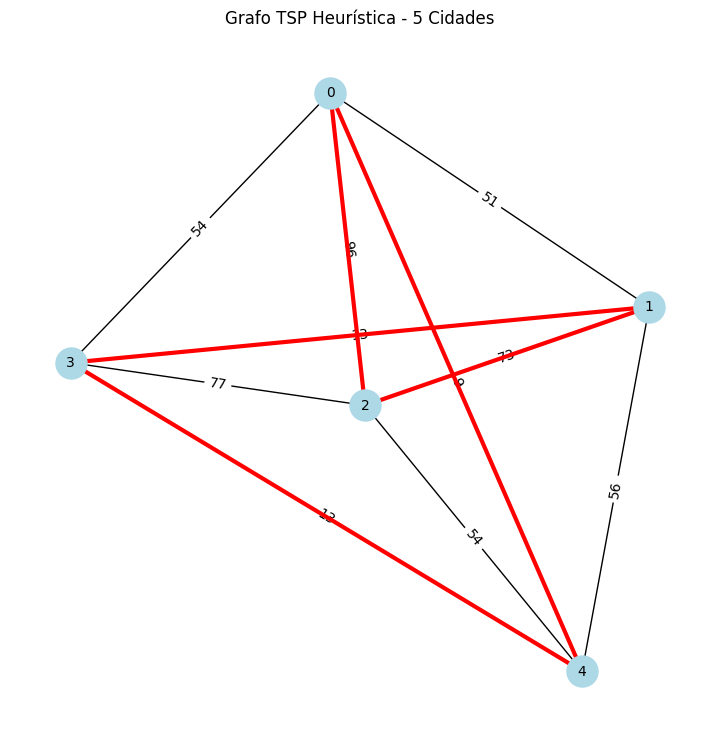

Matriz para 6 cidades:
[[ 0  8 67 88 36 53]
 [ 8  0 55 20 87 65]
 [67 55  0 97 63 38]
 [88 20 97  0 20 28]
 [36 87 63 20  0 53]
 [53 65 38 28 53  0]]
6 cidades (heurística): tempo = 0.0000s, distância = 206, rota = [0, 1, 3, 4, 5, 2, 0]


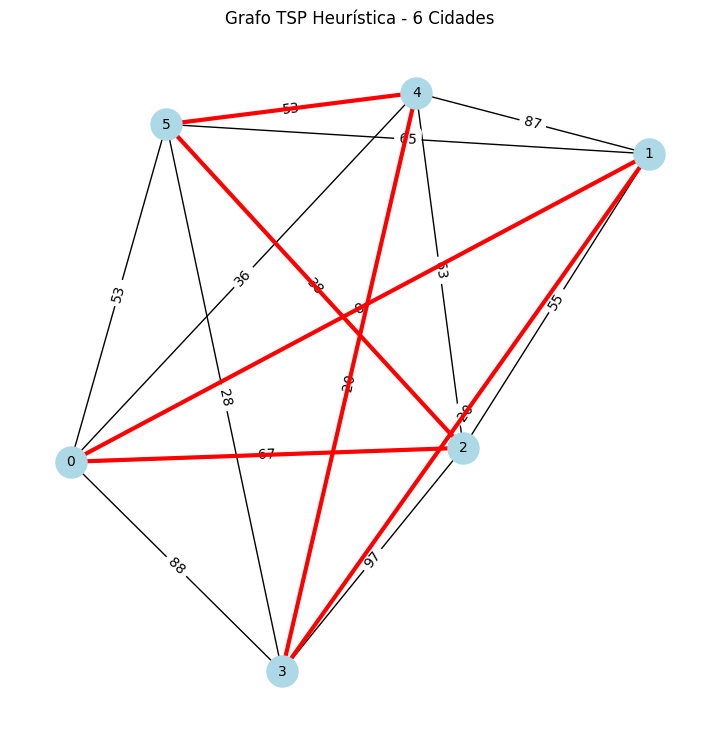

Matriz para 7 cidades:
[[  0  18  84  20  77  87  95]
 [ 18   0  46  15  80  29  75]
 [ 84  46   0  44  78  53  21]
 [ 20  15  44   0   9  65  70]
 [ 77  80  78   9   0 100  92]
 [ 87  29  53  65 100   0  37]
 [ 95  75  21  70  92  37   0]]
7 cidades (heurística): tempo = 0.0000s, distância = 265, rota = [0, 1, 3, 4, 2, 6, 5, 0]


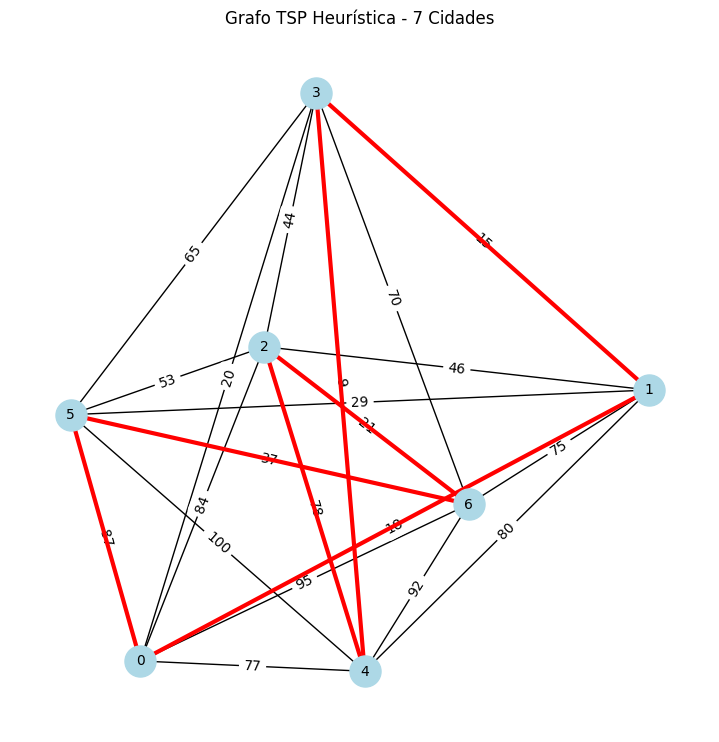

Matriz para 8 cidades:
[[ 0 75 66 41 31 19  1 65]
 [75  0 25 39 12  7 24 10]
 [66 25  0 53 33 36 40 75]
 [41 39 53  0 32  2 21  5]
 [31 12 33 32  0  1 56 81]
 [19  7 36  2  1  0 55 16]
 [ 1 24 40 21 56 55  0 20]
 [65 10 75  5 81 16 20  0]]
8 cidades (heurística): tempo = 0.0000s, distância = 132, rota = [0, 6, 7, 3, 5, 4, 1, 2, 0]


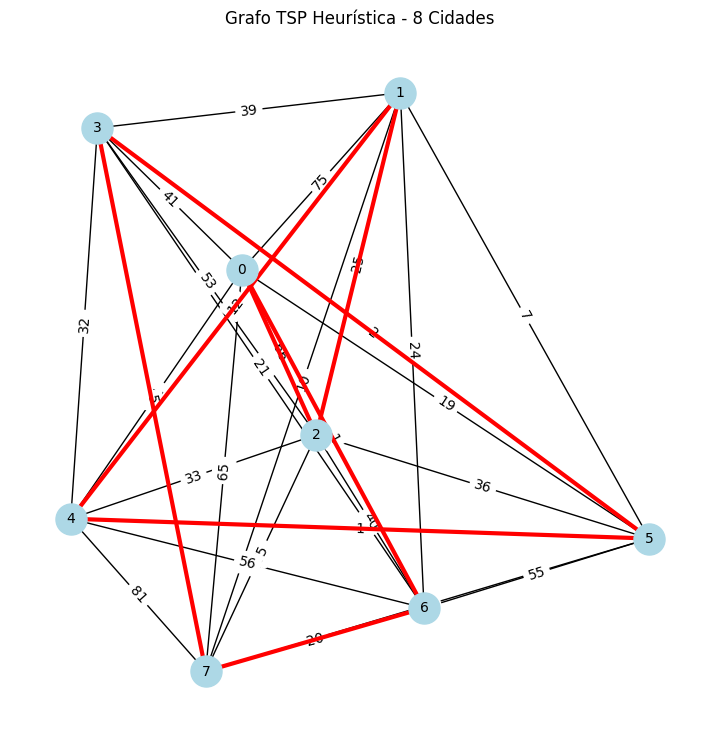

Matriz para 9 cidades:
[[ 0 17 76 99 51 65 79 56 35]
 [17  0 50 90 92  3 55 34 28]
 [76 50  0 50 43 72 41 27  3]
 [99 90 50  0 68 65  2 66 63]
 [51 92 43 68  0 54  9 49 73]
 [65  3 72 65 54  0 66 23 66]
 [79 55 41  2  9 66  0 26 67]
 [56 34 27 66 49 23 26  0 50]
 [35 28  3 63 73 66 67 50  0]]
9 cidades (heurística): tempo = 0.0001s, distância = 248, rota = [0, 1, 5, 7, 6, 3, 2, 8, 4, 0]


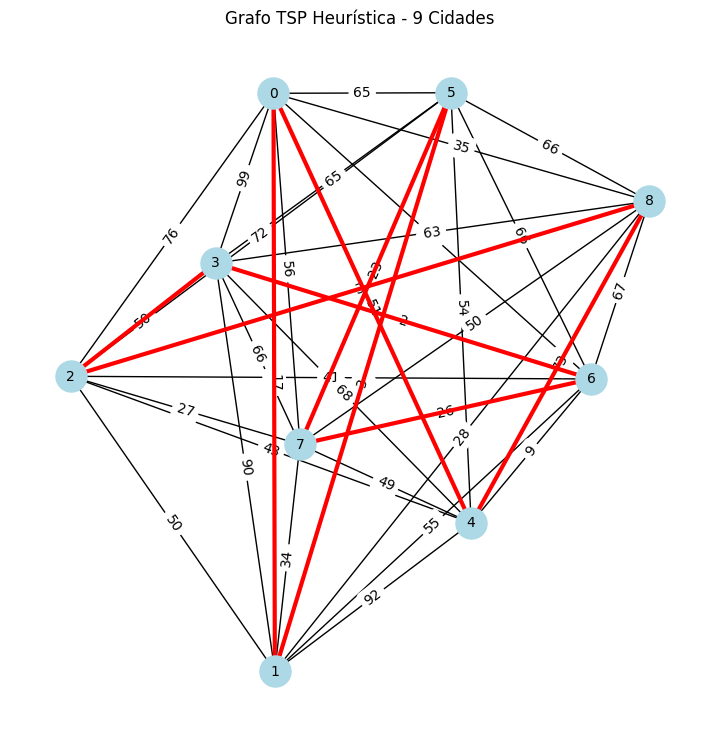

Matriz para 10 cidades:
[[ 0 49 73 86 50 31 62 19 44 71]
 [49  0  6 84 10 78 83  6 63 36]
 [73  6  0 55 67 33 29 66 35 73]
 [86 84 55  0 66 83 78 88  1 64]
 [50 10 67 66  0 69 87 31 16  3]
 [31 78 33 83 69  0 38 82 60 74]
 [62 83 29 78 87 38  0 25 82 55]
 [19  6 66 88 31 82 25  0 64 55]
 [44 63 35  1 16 60 82 64  0 73]
 [71 36 73 64  3 74 55 55 73  0]]
10 cidades (heurística): tempo = 0.0001s, distância = 276, rota = [0, 7, 1, 2, 6, 5, 8, 3, 9, 4, 0]


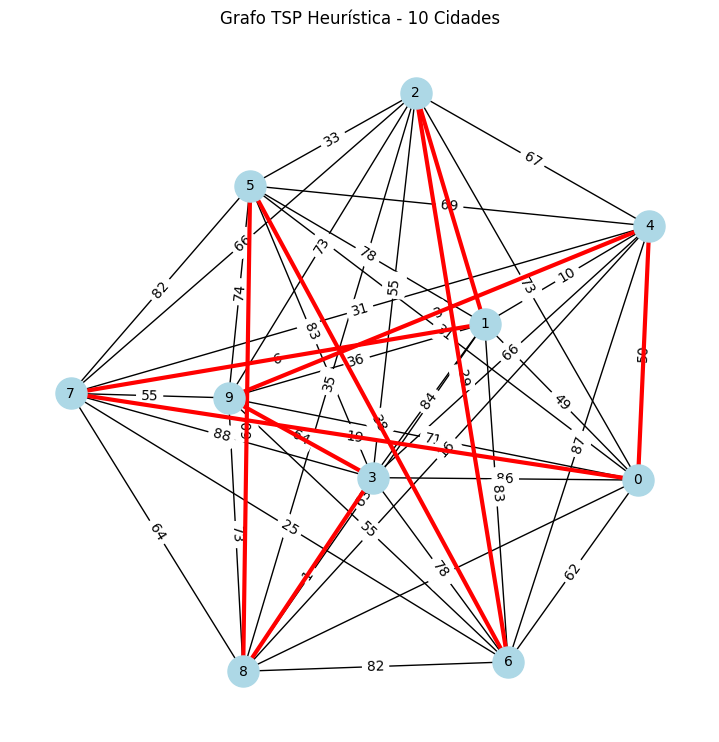

Matriz para 11 cidades:
[[  0  91  98  65   1  34  74   4  16  29 100]
 [ 91   0  90  39  34  13  98  81  33  41  63]
 [ 98  90   0  45  36  35  21  85  72  88  20]
 [ 65  39  45   0  17  12  14  54   2  98  44]
 [  1  34  36  17   0  93  85  54  70  55  87]
 [ 34  13  35  12  93   0  55  84   2  95  67]
 [ 74  98  21  14  85  55   0  63  59  63  34]
 [  4  81  85  54  54  84  63   0  94  15  79]
 [ 16  33  72   2  70   2  59  94   0  55  59]
 [ 29  41  88  98  55  95  63  15  55   0  90]
 [100  63  20  44  87  67  34  79  59  90   0]]
11 cidades (heurística): tempo = 0.0001s, distância = 295, rota = [0, 4, 3, 8, 5, 1, 9, 7, 6, 2, 10, 0]


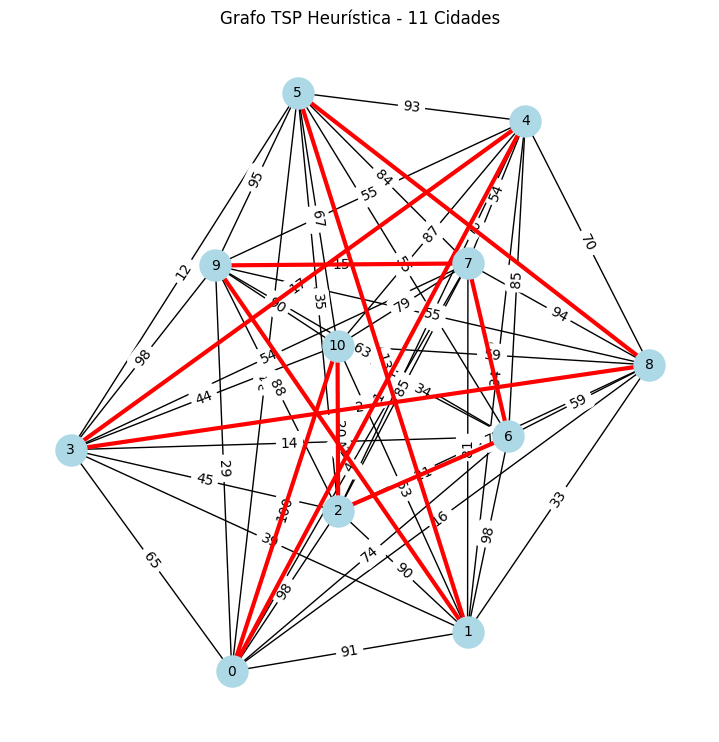

Matriz para 12 cidades:
[[  0  32  87  19  78  37  82  99  88   7  40  27]
 [ 32   0  80  67  29  55  83  20  59  93   6  53]
 [ 87  80   0  90  33  55  31   1  65   6  11 100]
 [ 19  67  90   0  89  51  31  97  50  24  10  71]
 [ 78  29  33  89   0  38  83  63  93  25  72  85]
 [ 37  55  55  51  38   0   4  99  73  82  53   8]
 [ 82  83  31  31  83   4   0  10  19  84   8  15]
 [ 99  20   1  97  63  99  10   0  97  10  45  54]
 [ 88  59  65  50  93  73  19  97   0  28  56  78]
 [  7  93   6  24  25  82  84  10  28   0  34  26]
 [ 40   6  11  10  72  53   8  45  56  34   0  91]
 [ 27  53 100  71  85   8  15  54  78  26  91   0]]
12 cidades (heurística): tempo = 0.0001s, distância = 326, rota = [0, 9, 2, 7, 6, 5, 11, 1, 10, 3, 8, 4, 0]


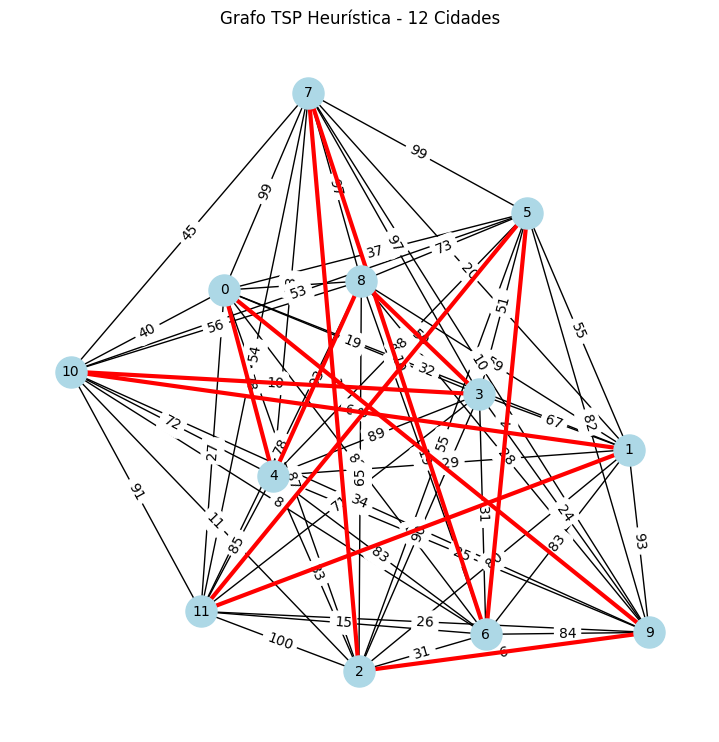

Matriz para 13 cidades:
[[  0  97  62  23  35  27  12  59  14  26  98  46  23]
 [ 97   0  96  66  35  87  66  30  89  67  92  97  98]
 [ 62  96   0  96  54  33  91  80  44  60  90  49  96]
 [ 23  66  96   0  78  83   3  26  65  46  50  75  29]
 [ 35  35  54  78   0  74  41  89  45  53  53  14  36]
 [ 27  87  33  83  74   0  71  79  76  82  79  95  50]
 [ 12  66  91   3  41  71   0  73  21  42  14  45   7]
 [ 59  30  80  26  89  79  73   0  43 100  75  38  49]
 [ 14  89  44  65  45  76  21  43   0  91  39  27  25]
 [ 26  67  60  46  53  82  42 100  91   0  39  16  48]
 [ 98  92  90  50  53  79  14  75  39  39   0  74   7]
 [ 46  97  49  75  14  95  45  38  27  16  74   0  49]
 [ 23  98  96  29  36  50   7  49  25  48   7  49   0]]
13 cidades (heurística): tempo = 0.0002s, distância = 311, rota = [0, 6, 3, 7, 1, 4, 11, 9, 10, 12, 8, 2, 5, 0]


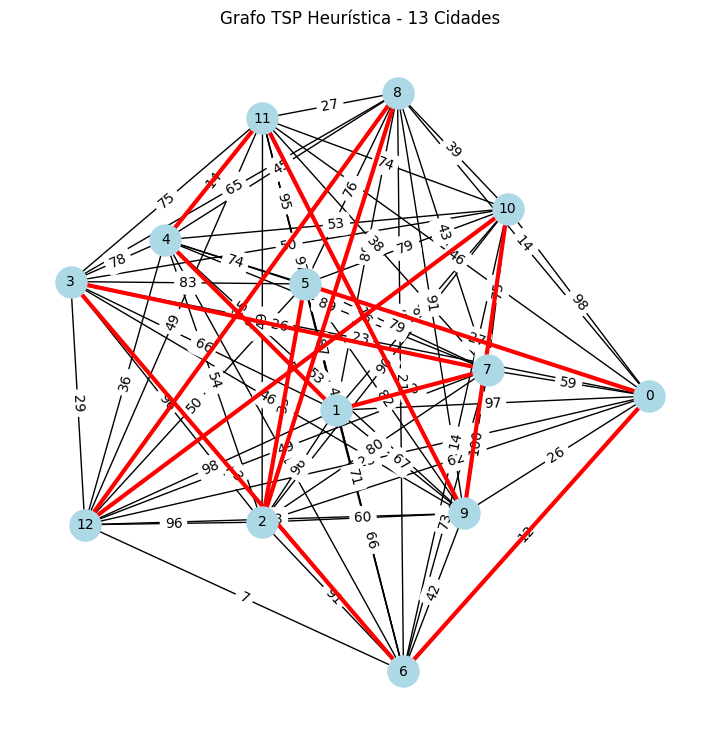

In [80]:
tempos_heuristica = []
distancias_heuristica = []
ns = list(range(2, 14))
for n in ns:
    matriz = gerar_matriz_tsp(n)
    inicio = time.time()
    rota_h, dist_h = tsp_vizinho_mais_proximo(matriz)
    fim = time.time()
    tempos_heuristica.append(fim - inicio)
    distancias_heuristica.append(dist_h)
    print(f'Matriz para {n} cidades:')
    print(matriz)
    print(f'{n} cidades (heurística): tempo = {tempos_heuristica[-1]:.4f}s, distância = {dist_h}, rota = {rota_h}')
    plotar_grafo_tsp(matriz, rota=rota_h, title=f"Grafo TSP Heurística - {n} Cidades", nome_arquivo=f"grafo_heuristica_{n}_cidades.png")

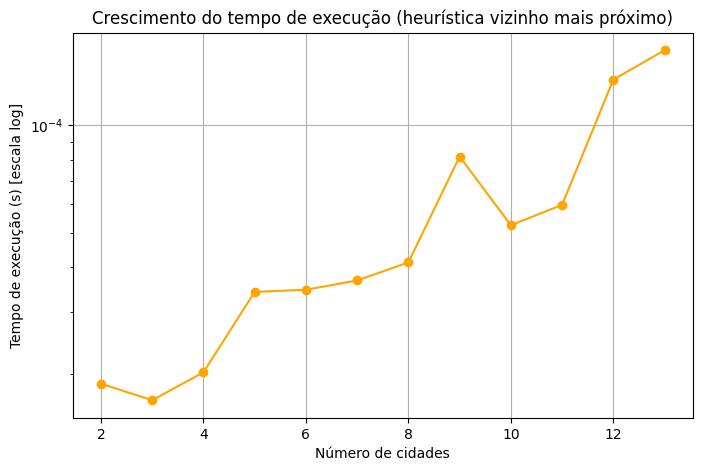

In [81]:
import os
# Criando o diretório para salvar os gráficos, se não existir
if not os.path.exists('graficos'):
    os.makedirs('graficos')

plt.figure(figsize=(8,5))
plt.plot(ns, tempos_heuristica, marker='o', color='orange')
plt.yscale('log')
plt.xlabel('Número de cidades')
plt.ylabel('Tempo de execução (s) [escala log]')
plt.title('Crescimento do tempo de execução (heurística vizinho mais próximo)')
plt.grid(True)
plt.savefig('graficos/grafico_tempo_heuristica.png')
plt.show()

### 2. Aplicar a Heuristica 

Nesta etapa, vamos ler os arquivos .tsp fornecidos (matriz de adjacência superior/inferior) e convertê-los para matriz de adjacência completa.

#### 2.1 si535.tsp

Descrição: Instância do TSP com 535 cidades.
Formato: Matriz de adjacência, apenas a diagonal superior (EDGE_WEIGHT_FORMAT: UPPER_DIAG_ROW).
Como funciona:
Os pesos das arestas estão dispostos apenas na parte superior da matriz (incluindo a diagonal principal).
Para reconstruir a matriz completa, basta preencher a parte inferior com os mesmos valores da superior, pois o grafo é simétrico.
Uso: Para ler corretamente, utilize um método que leia a diagonal superior e replique os valores para a parte inferior.

In [82]:
def ler_tsp_diagonal_superior(path):
    import numpy as np
    n = None
    with open(path, 'r') as f:
        for linha in f:
            if linha.startswith("DIMENSION"):
                n = int(linha.split(":")[1].strip())
            if linha.strip() == "EDGE_WEIGHT_SECTION":
                break
        # Lê todos os números da seção, independentemente das quebras de linha
        numeros = []
        for linha in f:
            linha = linha.strip()
            if not linha or not (linha[0].isdigit() or linha[0] == '0'):
                continue
            numeros += list(map(int, linha.split()))
            if len(numeros) >= (n * (n + 1)) // 2:
                break
    if n is None:
        raise ValueError("DIMENSION não encontrada no arquivo.")
    matriz = np.zeros((n, n), dtype=int)
    idx = 0
    for i in range(n):
        for j in range(i, n):
            matriz[i, j] = numeros[idx]
            matriz[j, i] = numeros[idx]
            idx += 1
    return matriz

# Exemplo de uso:
matriz_si535 = ler_tsp_diagonal_superior('data/si535.tsp')
print(matriz_si535.shape)

(535, 535)


#### 2.2 pa561.tsp

Descrição: Instância do TSP com 561 cidades.
Formato: Matriz de adjacência, apenas a diagonal inferior (EDGE_WEIGHT_FORMAT: LOWER_DIAG_ROW).
Como funciona:
Os pesos das arestas estão dispostos apenas na parte inferior da matriz (incluindo a diagonal principal).
Para reconstruir a matriz completa, basta preencher a parte superior com os mesmos valores da inferior, pois o grafo é simétrico.
Uso: Para ler corretamente, utilize um método que leia a diagonal inferior e replique os valores para a parte superior.

In [83]:
def ler_tsp_diagonal_inferior(path):
    import numpy as np
    n = None
    with open(path, 'r') as f:
        for linha in f:
            if linha.startswith("DIMENSION"):
                n = int(linha.split(":")[1].strip())
            if linha.strip() == "EDGE_WEIGHT_SECTION":
                break
        # Lê todos os números da seção, independentemente das quebras de linha
        numeros = []
        for linha in f:
            linha = linha.strip()
            if not linha or not (linha[0].isdigit() or linha[0] == '0'):
                continue
            numeros += list(map(int, linha.split()))
            if len(numeros) >= (n * (n + 1)) // 2:
                break
    if n is None:
        raise ValueError("DIMENSION não encontrada no arquivo.")
    matriz = np.zeros((n, n), dtype=int)
    idx = 0
    for i in range(n):
        for j in range(i + 1):
            matriz[i, j] = numeros[idx]
            matriz[j, i] = numeros[idx]
            idx += 1
    return matriz

# Exemplo de uso:
matriz_pa561 = ler_tsp_diagonal_inferior('data/pa561.tsp')
print(matriz_pa561.shape)

(561, 561)


#### 2.3 si1032.tsp

Descrição: Instância do TSP com 1032 cidades.
Formato: Matriz de adjacência, apenas a diagonal superior (EDGE_WEIGHT_FORMAT: UPPER_DIAG_ROW).
Como funciona:
Igual ao arquivo si535.tsp, os pesos estão apenas na parte superior da matriz.
Para reconstruir a matriz completa, replique os valores para a parte inferior.
Uso: Use o mesmo método de leitura da diagonal superior.


In [73]:
def ler_tsp_diagonal_superior(path):
    import numpy as np
    n = None
    with open(path, 'r') as f:
        for linha in f:
            if linha.startswith("DIMENSION"):
                n = int(linha.split(":")[1].strip())
            if linha.strip() == "EDGE_WEIGHT_SECTION":
                break
        # Lê todos os números da seção, independentemente das quebras de linha
        numeros = []
        for linha in f:
            linha = linha.strip()
            if not linha or not (linha[0].isdigit() or linha[0] == '0'):
                continue
            numeros += list(map(int, linha.split()))
            if len(numeros) >= (n * (n + 1)) // 2:
                break
    if n is None:
        raise ValueError("DIMENSION não encontrada no arquivo.")
    matriz = np.zeros((n, n), dtype=int)
    idx = 0
    for i in range(n):
        for j in range(i, n):
            matriz[i, j] = numeros[idx]
            matriz[j, i] = numeros[idx]
            idx += 1
    return matriz

# Exemplo de uso:
matriz_si1032 = ler_tsp_diagonal_superior('data/si1032.tsp')
print(matriz_si1032.shape)  # Deve mostrar (1032, 1032)

(1032, 1032)


#### 3. Aplicação da Heurística nas Instâncias

Aplicamos a heurística implementada nas três instâncias reais e calculamos as rotas.

In [74]:
matriz_si535 = ler_tsp_diagonal_superior('data/si535.tsp')
matriz_pa561 = ler_tsp_diagonal_inferior('data/pa561.tsp')
matriz_si1032 = ler_tsp_diagonal_superior('data/si1032.tsp')

# Calculando as rotas e distâncias
resultados = {}
resultados['si535'] = tsp_vizinho_mais_proximo(matriz_si535)
resultados['pa561'] = tsp_vizinho_mais_proximo(matriz_pa561)
resultados['si1032'] = tsp_vizinho_mais_proximo(matriz_si1032)

# Agora você pode exibir os resultados
for nome, (rota, dist) in resultados.items():
    print(f'Instância {nome}: distância encontrada pela heurística = {dist}')

Instância si535: distância encontrada pela heurística = 50144
Instância pa561: distância encontrada pela heurística = 3422
Instância si1032: distância encontrada pela heurística = 94571
